### Mount Google Drive

To access your dataset stored in Google Drive, you'll need to mount it to your Colab environment. Run the following cell and follow the instructions to authenticate.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Define Dataset Path

Now that your Google Drive is mounted, you need to specify the path to your dataset. Based on the link you provided, your dataset is likely located in a folder named `animal_images` or similar within your Drive. Please adjust the `dataset_path` variable if the actual path is different.

After defining the path, we will list the contents to confirm the directories are correctly identified.

In [3]:
import os

# Define the base path to your dataset within Google Drive
# Adjust this path if your dataset is located elsewhere in your Google Drive
dataset_path = '/content/drive/MyDrive/Animal Image Data/dataset'

# Verify if the path exists
if not os.path.exists(dataset_path):
    print(f"Error: The specified path does not exist: {dataset_path}")
    print("Please check the path and ensure your dataset is correctly placed in your Google Drive.")
else:
    print(f"Dataset path set to: {dataset_path}")
    print("Listing contents of the dataset directory:")
    print(os.listdir(dataset_path))

Dataset path set to: /content/drive/MyDrive/Animal Image Data/dataset
Listing contents of the dataset directory:
['Dog', 'Giraffe', 'Elephant', 'Horse', 'Dolphin', 'Cow', 'Deer', 'Cat', 'Bird', 'Bear']


### Load Dataset

Now, we'll load the image data from the specified directory using `tf.keras.utils.image_dataset_from_directory`. This function is convenient for datasets organized into subdirectories, where each subdirectory represents a class. We'll also create training and validation splits.

In [4]:
import tensorflow as tf

# Define image dimensions and batch size
img_height = 224
img_width = 224
batch_size = 32

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

print("\nDatasets loaded successfully!")
print(f"Number of training batches: {len(train_ds)}")
print(f"Number of validation batches: {len(val_ds)}")

# Get class names
class_names = train_ds.class_names
print(f"Class names: {class_names}")

Found 1238 files belonging to 10 classes.
Using 991 files for training.
Found 1238 files belonging to 10 classes.
Using 247 files for validation.

Datasets loaded successfully!
Number of training batches: 31
Number of validation batches: 8
Class names: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse']


### Data Preprocessing and Optimization

To prepare the images for training a neural network, we need to perform two key steps:

1.  **Normalization**: Rescale pixel values from the `[0, 255]` range to `[0, 1]`. This helps in faster convergence during training.
2.  **Caching and Prefetching**: Optimize dataset loading by caching data to disk and prefetching elements in the background, which prevents I/O from blocking the training step.

In [5]:
# Create a function for data normalization
def normalize_img(image, label):
    # Normalize images to a [0, 1] range
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

# Apply normalization to the training and validation datasets
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(normalize_img, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(normalize_img, num_parallel_calls=AUTOTUNE)

# Cache and prefetch for optimized performance
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Data preprocessing and optimization complete!")

Data preprocessing and optimization complete!


### Build the Model

Now we will define the architecture of our convolutional neural network (CNN). We'll start with a simple model. Remember, for more advanced solutions, you might consider using transfer learning with pre-trained models.

In [6]:
num_classes = len(class_names)

model = tf.keras.Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)), # Already normalized, but good practice for first layer
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes, activation='softmax') # Use softmax for multi-class classification
])

model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
  metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,447,530 (24.60 MB)

 Trainable params: 6,447,530 (24.60 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

Now we will train the defined CNN model using the training dataset and evaluate its performance on the validation dataset.

In [7]:
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

print("\nModel training complete!")

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 358s 11s/step - accuracy: 0.0888 - loss: 2.3020 - val_accuracy: 0.1093 - val_loss: 2.3009
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.1070 - loss: 2.2994 - val_accuracy: 0.0850 - val_loss: 2.3024
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.1100 - loss: 2.2976 - val_accuracy: 0.0850 - val_loss: 2.3032
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.1171 - loss: 2.2969 - val_accuracy: 0.0850 - val_loss: 2.3037
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.1171 - loss: 2.2967 - val_accuracy: 0.0850 - val_loss: 2.3040
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.1171 - loss: 2.2964 - val_accuracy: 0.0850 - val_loss: 2.3043
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.1171 - loss: 2.2963 - val_accuracy: 0.0850 - val_loss: 2.3045
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.1171 - loss: 2.2961 - val_accuracy: 0.0850 - val_los

### Visualize Training Results

Let's plot the training and validation accuracy and loss to see how our model performed over the epochs. This helps us understand if the model is learning effectively or if there are signs of overfitting or underfitting.

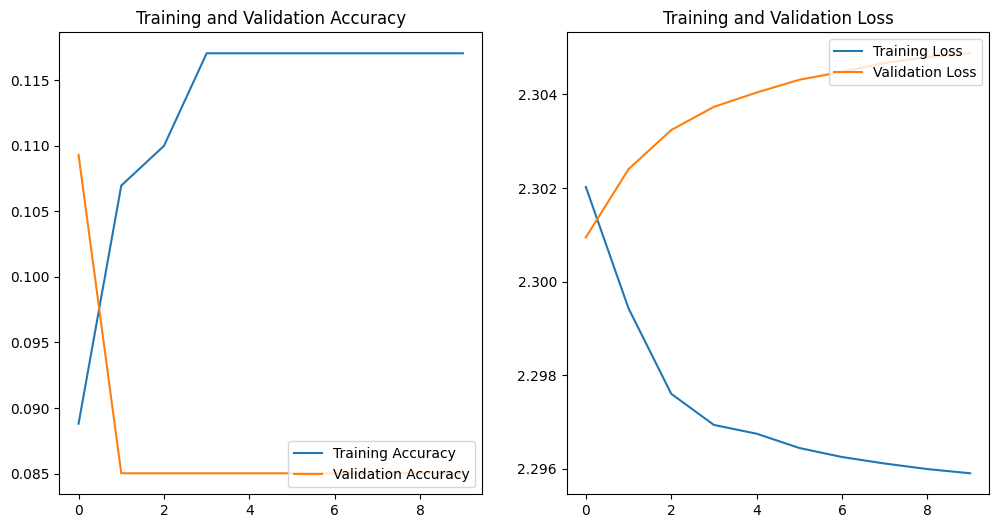

In [8]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Improving Model Performance with Transfer Learning and Data Augmentation

As observed from the previous training results, the simple CNN model struggled to learn effectively, indicating underfitting. To address this, we will employ two powerful techniques:

1.  **Transfer Learning**: We will use a pre-trained model (MobileNetV2, trained on ImageNet) as a base. This model has already learned a rich set of features from a very large dataset, which we can leverage for our task. We will keep its convolutional base frozen and add a new classification head.
2.  **Data Augmentation**: To prevent overfitting, especially with a relatively smaller dataset, we will apply various transformations to our training images (e.g., random flips, rotations, zoom). This artificially increases the diversity of our training data.

We will also add more evaluation metrics (Precision, Recall, F1-Score) to get a more detailed understanding of the model's performance beyond just accuracy.

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.metrics import Precision, Recall # Reverting to standard Precision and Recall

# Define data augmentation layers
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2)
])

print("Data augmentation layers defined.")

Data augmentation layers defined.


### Build the Transfer Learning Model

We will now load the pre-trained MobileNetV2 model, freeze its base layers, and add our custom classification head with data augmentation.

In [19]:
# Create the base model from the pre-trained MobileNetV2
IMG_SHAPE = (img_height, img_width, 3)
base_model = MobileNetV2(input_shape=IMG_SHAPE,
                         include_top=False, # Do not include the ImageNet classifier at the top
                         weights='imagenet')

# Freeze the convolutional base
base_model.trainable = False

# Build the new model on top of the base model
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = base_model(x, training=False) # Ensure the base model is run in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Add a dropout layer for regularization
outputs = layers.Dense(num_classes)(x) # Removed activation='softmax' to output logits

model_tl = models.Model(inputs, outputs)

model_tl.summary()
print("Transfer Learning model built and base layers frozen.")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Transfer Learning model built and base layers frozen.


### Compile the Transfer Learning Model

We will compile the new model, including `Precision` and `Recall` metrics for a more detailed evaluation.

In [35]:
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'] # Temporarily removed Precision() and Recall() due to IncompatibleShapes error
)
print("Transfer Learning model compiled with new metrics (accuracy only for now).")

Transfer Learning model compiled with new metrics (accuracy only for now).


### Train the Transfer Learning Model

Now, let's train our new model with the pre-trained base and data augmentation. We'll start with a few epochs to see the initial performance.

In [38]:
epochs_tl = 20 # Increased number of epochs for fine-tuning
history_tl = model_tl.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs_tl
)

print("Transfer Learning model training complete!")

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.5913 - loss: 1.3672 - val_accuracy: 0.7206 - val_loss: 1.1820
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.5994 - loss: 1.3356 - val_accuracy: 0.7530 - val_loss: 1.1145
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.5913 - loss: 1.3066 - val_accuracy: 0.7652 - val_loss: 1.0648
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.6398 - loss: 1.1922 - val_accuracy: 0.7814 - val_loss: 1.0144
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.6408 - loss: 1.1675 - val_accuracy: 0.7895 - val_loss: 0.9708
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.6680 - loss: 1.1229 - val_accuracy: 0.7895 - val_loss: 0.9341
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.6771 - loss: 1.1017 - val_accuracy: 0.8057 - val_loss: 0.8975
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.6791 - loss: 1.0612 - val_accuracy: 0.8097 - val_loss:

### Visualize Transfer Learning Training Results

Let's visualize the training and validation accuracy and loss for our transfer learning model to see the improvement.

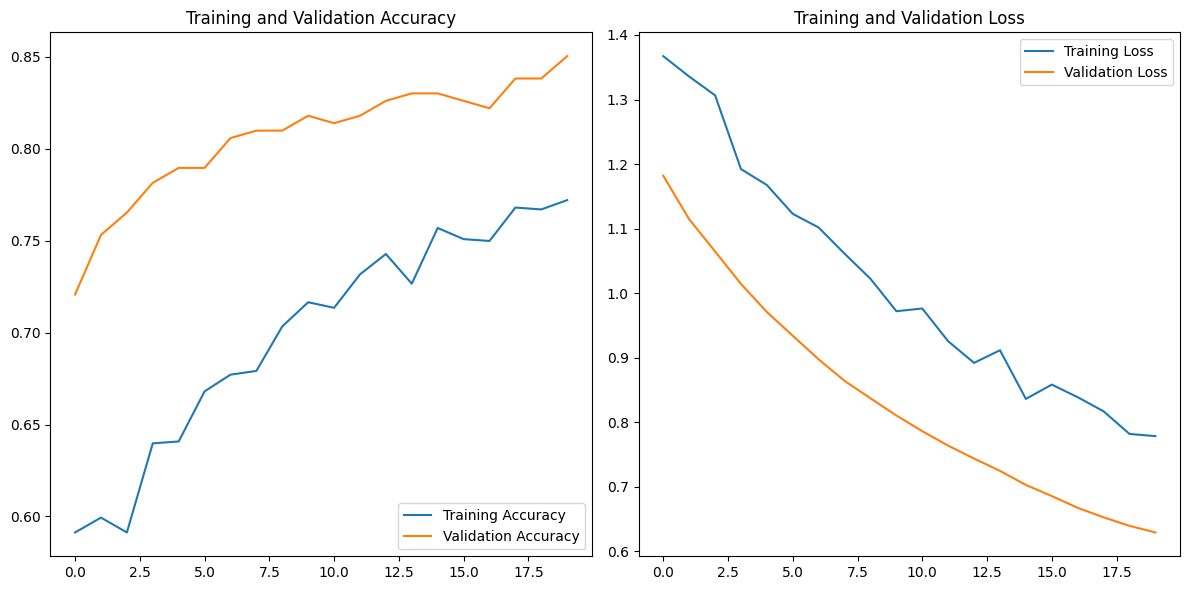

In [39]:
import matplotlib.pyplot as plt

acc_tl = history_tl.history['accuracy']
val_acc_tl = history_tl.history['val_accuracy']

loss_tl = history_tl.history['loss']
val_loss_tl = history_tl.history['val_loss']

epochs_range_tl = range(epochs_tl)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # Changed to 1x2 layout as Precision and Recall are not available
plt.plot(epochs_range_tl, acc_tl, label='Training Accuracy')
plt.plot(epochs_range_tl, val_acc_tl, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2) # Changed to 1x2 layout
plt.plot(epochs_range_tl, loss_tl, label='Training Loss')
plt.plot(epochs_range_tl, val_loss_tl, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

### Make Predictions with the Transfer Learning Model

Now that we have a trained model, let's use it to make predictions on a few sample images. We'll pick an image from our validation set and see what the model predicts.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


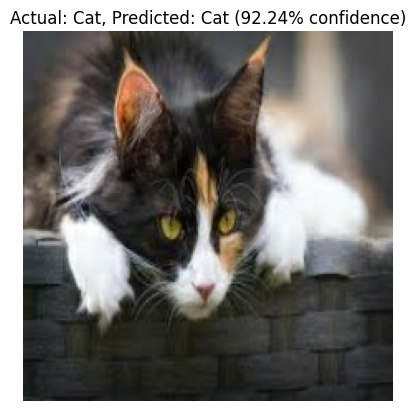

In [40]:
import numpy as np

# Get a batch of images and labels from the validation dataset
for images, labels in val_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0].numpy()
    break

# Expand dimensions to create a batch of 1 image
img_array = tf.expand_dims(sample_image, 0)

# Make prediction
predictions = model_tl.predict(img_array)

# Since the model now outputs logits, apply softmax to get probabilities for prediction
score = tf.nn.softmax(predictions[0])

# Get the predicted class name
predicted_class_index = np.argmax(score)
predicted_class_name = class_names[predicted_class_index]
actual_class_name = class_names[sample_label]

# Display the image and prediction
plt.imshow(sample_image)
plt.title(f"Actual: {actual_class_name}, Predicted: {predicted_class_name} ({100 * np.max(score):.2f}% confidence)")
plt.axis('off')
plt.show()


### Model Evaluation: Beyond Accuracy

To get a more complete understanding of our model's performance, especially given potential class imbalances, we'll evaluate it using metrics beyond just accuracy. We will calculate:

*   **Precision**: The proportion of positive identifications that were actually correct.
*   **Recall**: The proportion of actual positives that were identified correctly.
*   **F1-Score**: The harmonic mean of Precision and Recall, providing a balance between the two.
*   **Confusion Matrix**: A table that describes the performance of a classification model on a set of test data for which the true values are known. It allows visualization of the performance of an algorithm.

Since `Precision()` and `Recall()` metrics during compilation caused issues, we will compute these metrics manually after training using `sklearn.metrics`.


Classification Report:
              precision    recall  f1-score   support

        Bear       0.72      0.88      0.79        24
        Bird       0.95      0.86      0.90        21
         Cat       1.00      1.00      1.00        25
         Cow       0.87      0.71      0.78        38
        Deer       0.85      0.88      0.87        33
         Dog       0.79      0.83      0.81        18
     Dolphin       0.81      0.93      0.86        27
    Elephant       0.71      0.81      0.76        27
     Giraffe       1.00      0.95      0.97        19
       Horse       1.00      0.67      0.80        15

    accuracy                           0.85       247
   macro avg       0.87      0.85      0.85       247
weighted avg       0.86      0.85      0.85       247



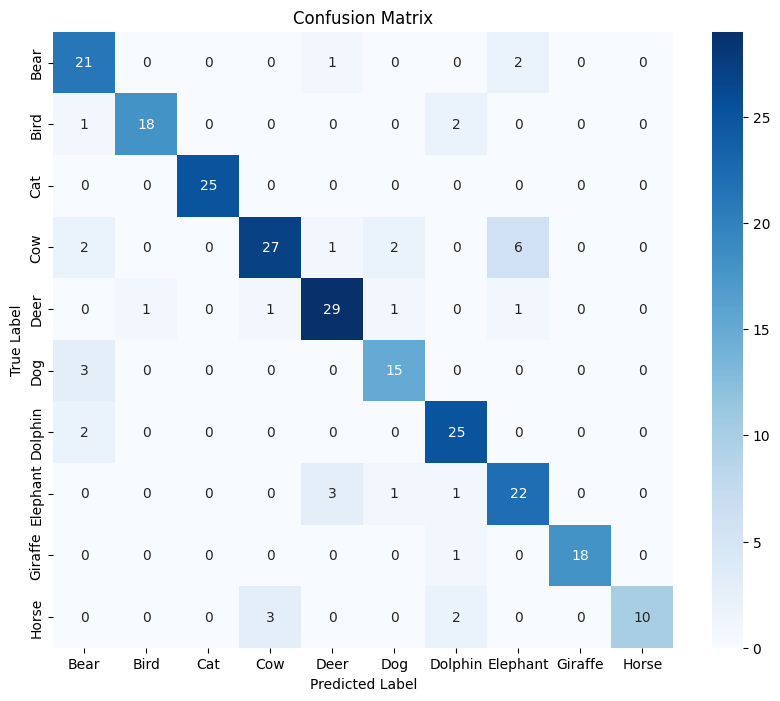

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gather all true labels and predictions from the validation set
y_true = []
y_pred_logits = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    predictions = model_tl.predict(images, verbose=0) # Make predictions on the batch
    y_pred_logits.extend(predictions) # Store raw logits

y_true = np.array(y_true)
y_pred_logits = np.array(y_pred_logits)
y_pred = np.argmax(tf.nn.softmax(y_pred_logits, axis=-1), axis=1) # Apply softmax and argmax to get predicted class

# Generate Classification Report (includes Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
